# Raman Fitting Example: Bi-layer Graphene

This example shows Raman fitting for bi-layer graphene Raman spectrum. The spectrum contains multiple overlapping peaks, including the G peak and the 2D peak, which can be deconvoluted using multiple Lorentzian functions. We will demonstrate how to set up the fitting process using the `RamanFit` class from the `RamanPL_2D` package with appropriate background removal and peak fitting.

Expt setting:

- Data collection time: 2023/3/26
- Sampling site: on Se flakes
- Exposure time: 1s
- Laser Power: 50%
- magnification: 20x
- Accumulation: 10
- Laser setting: central $\lambda$ = 520 cm^-1 ; laser = `532`nm ; grating: 1800 vis

## 1. Using `poly` baseline method for background removal

C:\Users\44752\AppData\Local\Temp\ipykernel_19232\1199973776.py:11: DeprecationWarning: baseline_method=('poly', degree) is deprecated and will be removed in a future version. Use baseline_method={'method': 'poly', 'poly_degree': degree} instead.
  raman_fit = RamanFit.RamanFit(spectra, wavenumber,
D:\OneDrive - University of Cambridge\9 Expt results\Raman\00A_data_analysis_source code\RamanPL_2D\src\ramanpl\preprocessing.py:231: FutureWarning: 
Legacy parameters (poly_degree / gaussian_sigma) are ignored when baseline_method is provided as a dict.
Please remove legacy parameters.
  method, bkwargs = BaselineAPI.parse_spec(


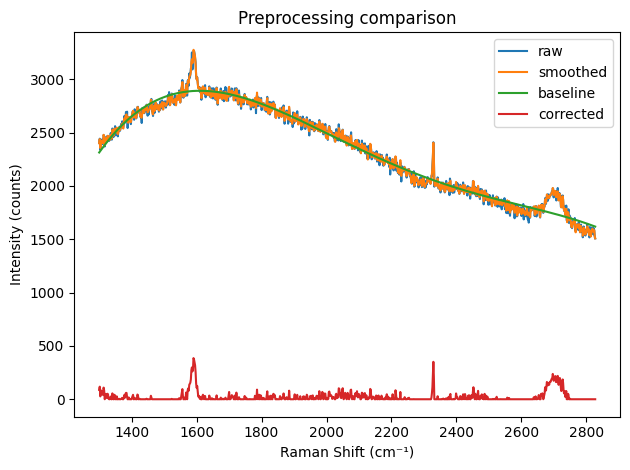


Peak                 Position(cm⁻¹)  FWHM(cm⁻¹)    Peak height    Scale     
--------------------------------------------------------------------------------
G                    1590.64         13.30         369.06         6.65      
2D-1B                2600.00         20.00         0.00           10.00     
2D-1A                2650.00         20.00         2.35           10.00     
2D-2A                2694.64         20.00         224.19         10.00     
2D-2B                2716.22         16.89         145.35         8.44      

Normalized Residual: 0.2860 (0 = perfect fit)


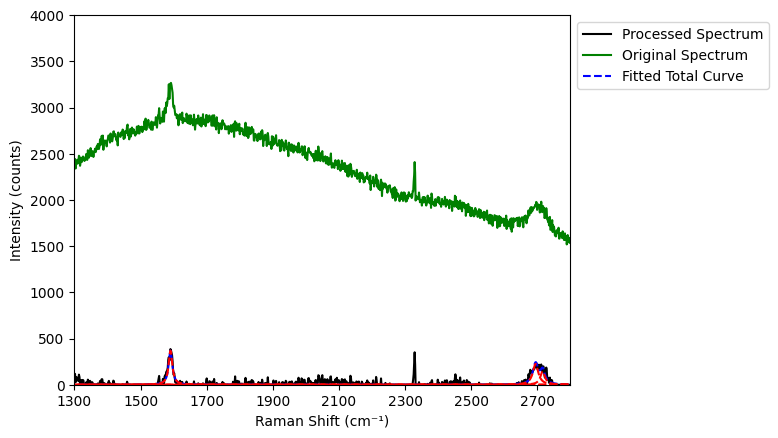

In [1]:
from ramanpl import RamanFit

# Import data from WDF file
spectra, wavenumber = RamanFit.DataImporter.data_import(
    filename='Raman Sample 532nm 2L-Graphene.txt',
    # readlines=[0, 1012]                         # Deprected: Read all data lines
    x_range=(1300, 2900)    # Specify the x-axis range to read (in cm^-1)
)

# Instantiate the RamanFit class
raman_fit = RamanFit.RamanFit(spectra, wavenumber,
                     materials=['2L-Gr'],      # Load materials; here we have "Gr" for graphene and "2L-Gr" for bilayer graphene, 
                                               # their component peaks in 2D curve differ significantly
                     substrate=None,           # Here the sample is loaded on Cu, which has no Raman spectra due to lack of polarisablity
                     normalize=False,           # Normalize your peak intensity, if needed
                     background_remove=True,   # If your Raman contains needs remove background intensity, use this
                     baseline_method=("poly", 4), # Method to remove background, here we use polynomial fitting with degree 3, you can also use "asymmetric_least_squares" or "rolling_ball"
                     smoothing=True,           # Smooth too noisy signal, only if needed
                     smooth_order=8            # smooth_order in range 1 to 10, where 1 means the strongest smooth
                     )

# Update the fitting bounds 
bounds_dict = {
    '2D-1B':  ([2600, 0, 0], [2620, 10, 10]),
    '2D-1A':  ([2620, 0, 0], [2650, 10, 20]),
    '2D-2A':  ([2650, 0, 0], [2700, 10, 20]),
    '2D-2B':  ([2700, 0, 0], [2720, 10, 10]),

}
raman_fit.update_bounds(**bounds_dict)

# Remove Unecessary peaks
raman_fit.remove_peaks('D')             # 'D' peak around 1400 cm-1 is only needed if you think sample is doped, we remove it in this example

# Perform the fitting
params, params_cov = raman_fit.fit_spectrum()

# Plot the results with an offset and scale
xlim = [1300, 2800]
raman_fit.plot_fit(params,                          # The Lorentzian parameters fitted 
                   offset=0, scale=1,               # Plot offset or scale of fitted curve relative to raw data
                   x_lim=xlim, y_lim=[0,4000],      # set x-y axis limits
                
                   # set x-axis ticks
                   x_ticks=range(xlim[0],xlim[1],200)
                   )

## 2. Using `asls` baseline method for background removal

The next cell will demonstrate background subtraction using `arpls` method (a.ka.a. "adaptive reweighted penalized least squares"). This method is more advanced and generally provides better baseline correction for Raman spectra with complex backgrounds.

Tuning rules:

- Baseline still “wavy” / tracking peaks → increase lam (e.g., 1e8, 1e9)

- Baseline too stiff / not removing curvature → decrease lam (e.g., 1e6)

- Baseline too high (eats peak foot) → decrease p (e.g., 0.005)

- Baseline too low → increase p (e.g., 0.02)

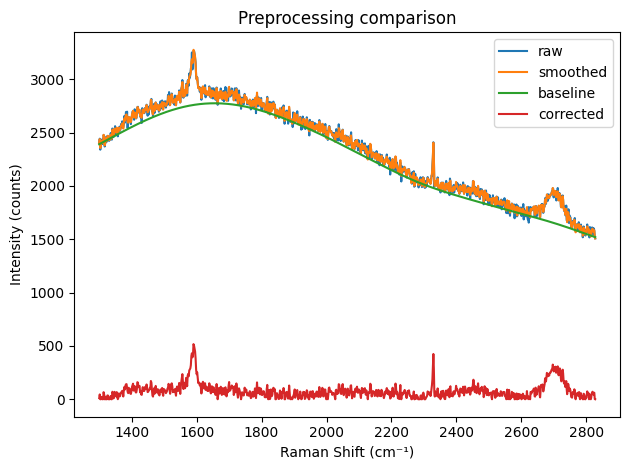


Peak                 Position(cm⁻¹)  FWHM(cm⁻¹)    Peak height    Scale     
--------------------------------------------------------------------------------
G                    1590.22         16.10         408.56         8.05      
2D-1B                2600.00         20.00         34.61          10.00     
2D-1A                2650.00         20.00         106.13         10.00     
2D-2A                2695.79         20.00         327.90         10.00     
2D-2B                2720.00         18.65         176.49         9.32      

Normalized Residual: 0.4908 (0 = perfect fit)


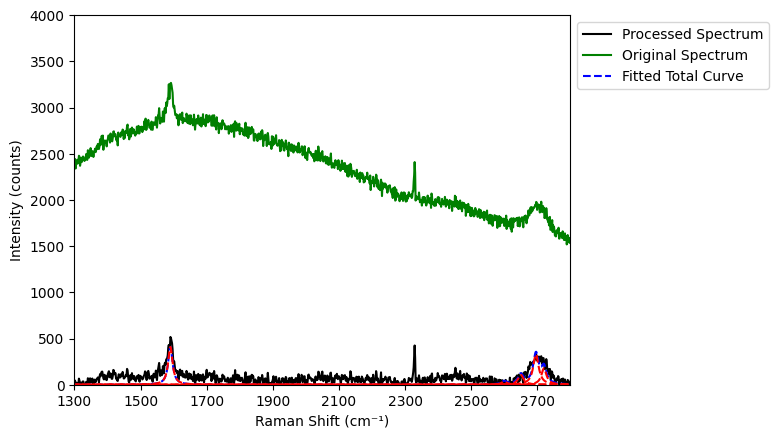

In [2]:
from ramanpl import RamanFit

# Import data from WDF file
spectra, wavenumber = RamanFit.DataImporter.data_import(
    filename='Raman Sample 532nm 2L-Graphene.txt',
    x_range=(1300, 2900)    # Specify the x-axis range to read (in cm^-1)
)

baseline_setting={"method": "asls", "lam": 1e6, "p": 0.01, "niter": 30}

# Instantiate the RamanFit class
raman_fit = RamanFit.RamanFit(
    spectra, wavenumber,
    materials=['2L-Gr'],
    substrate=None,
    normalize=False,
    background_remove=True,
    baseline_method={"method": "asls", "lam": 1e6, "p": 0.01, "niter": 30},
    smoothing=True,
    smooth_order=8
)

# Update the fitting bounds 
bounds_dict = {
    '2D-1B':  ([2600, 0, 0], [2620, 10, 10]),
    '2D-1A':  ([2620, 0, 0], [2650, 10, 20]),
    '2D-2A':  ([2650, 0, 0], [2700, 10, 20]),
    '2D-2B':  ([2700, 0, 0], [2720, 10, 10]),

}
raman_fit.update_bounds(**bounds_dict)

# Remove Unecessary peaks
raman_fit.remove_peaks('D')             # 'D' peak around 1400 cm-1 is only needed if you think sample is doped, we remove it in this example

# Perform the fitting
params, params_cov = raman_fit.fit_spectrum()

# Plot the results with an offset and scale
xlim = [1300, 2800]
raman_fit.plot_fit(params,                          # The Lorentzian parameters fitted 
                   offset=0, scale=1,               # Plot offset or scale of fitted curve relative to raw data
                   x_lim=xlim, y_lim=[0,4000],      # set x-y axis limits
                
                   # set x-axis ticks
                   x_ticks=range(xlim[0],xlim[1],200)
                   )

## 3. Using `arpls` baseline method for background removal
The cell below will demonstrate background subtraction using `arpls` method (a.ka.a. "adaptive reweighted penalized least squares"). This method is more advanced and generally provides better baseline correction for Raman spectra with asymmetric noise characteristics. This method is robust for general-purpose baseline correction.

Tuning rules:

- Over-correcting (baseline too low) → reduce lam

- Under-correcting (baseline too high) → increase lam

- Not converging well / inconsistent → increase niter to 100 and/or reduce tol to 1e-7

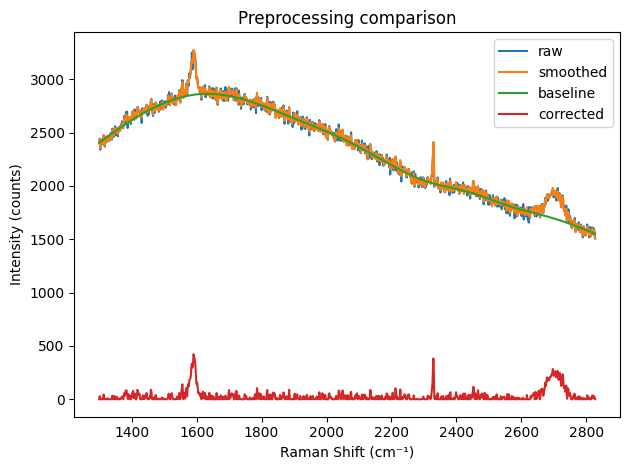


Peak                 Position(cm⁻¹)  FWHM(cm⁻¹)    Peak height    Scale     
--------------------------------------------------------------------------------
G                    1590.46         13.91         385.95         6.95      
2D-1B                2600.00         20.00         0.00           10.00     
2D-1A                2650.00         20.00         51.30          10.00     
2D-2A                2695.40         20.00         268.28         10.00     
2D-2B                2717.84         16.44         162.71         8.22      

Normalized Residual: 0.2692 (0 = perfect fit)


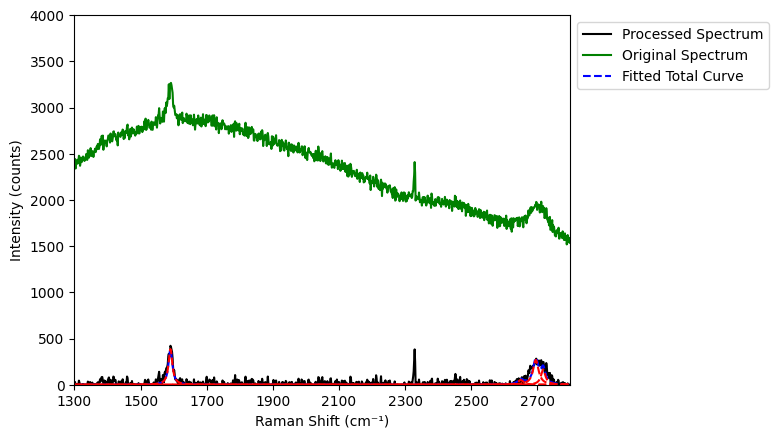

In [3]:
from ramanpl import RamanFit

# Import data from WDF file
spectra, wavenumber = RamanFit.DataImporter.data_import(
    filename='Raman Sample 532nm 2L-Graphene.txt',
    x_range=(1300, 2900)    # Specify the x-axis range to read (in cm^-1)
)

baseline_setting={"method": "arpls", "lam": 1e6, "niter": 50, "tol": 1e-6}

# Instantiate the RamanFit class
raman_fit = RamanFit.RamanFit(
    spectra, wavenumber,
    materials=['2L-Gr'],
    substrate=None,
    normalize=False,
    background_remove=True,
    baseline_method=baseline_setting,
    smoothing=True,
    smooth_order=8
)

# Update the fitting bounds 
bounds_dict = {
    '2D-1B':  ([2600, 0, 0], [2620, 10, 10]),
    '2D-1A':  ([2620, 0, 0], [2650, 10, 20]),
    '2D-2A':  ([2650, 0, 0], [2700, 10, 20]),
    '2D-2B':  ([2700, 0, 0], [2720, 10, 10]),

}
raman_fit.update_bounds(**bounds_dict)

# Remove Unecessary peaks
raman_fit.remove_peaks('D')             # 'D' peak around 1400 cm-1 is only needed if you think sample is doped, we remove it in this example

# Perform the fitting
params, params_cov = raman_fit.fit_spectrum()

# Plot the results with an offset and scale
xlim = [1300, 2800]
raman_fit.plot_fit(params,                          # The Lorentzian parameters fitted 
                   offset=0, scale=1,               # Plot offset or scale of fitted curve relative to raw data
                   x_lim=xlim, y_lim=[0,4000],      # set x-y axis limits
                
                   # set x-axis ticks
                   x_ticks=range(xlim[0],xlim[1],200)
                   )

## 3. Using `airpls` baseline method for background removal
The next cell will demonstrate background subtraction using `airpls` method (a.ka.a. "improved adaptive reweighted penalized least squares"). This method is more effective if peak sit on fluroescent background.

Tuning rules:

- Baseline still high near strong peaks → increase niter (e.g., 120) and/or reduce tol (e.g., 1e-7)

- Baseline becomes unstable → increase lam (e.g., 1e8)

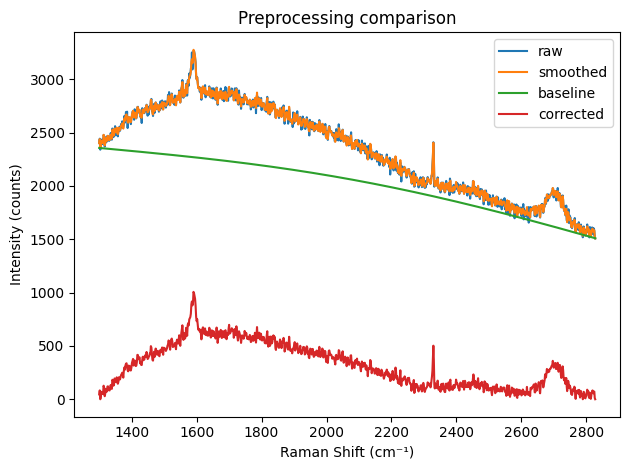


Peak                 Position(cm⁻¹)  FWHM(cm⁻¹)    Peak height    Scale     
--------------------------------------------------------------------------------
G                    1590.83         26.76         478.72         13.38     
2D-1B                2595.00         30.00         89.84          15.00     
2D-1A                2646.77         30.00         97.85          15.00     
2D-2A                2690.77         30.00         286.07         15.00     
2D-2B                2720.18         30.00         260.59         15.00     

Normalized Residual: 0.8588 (0 = perfect fit)


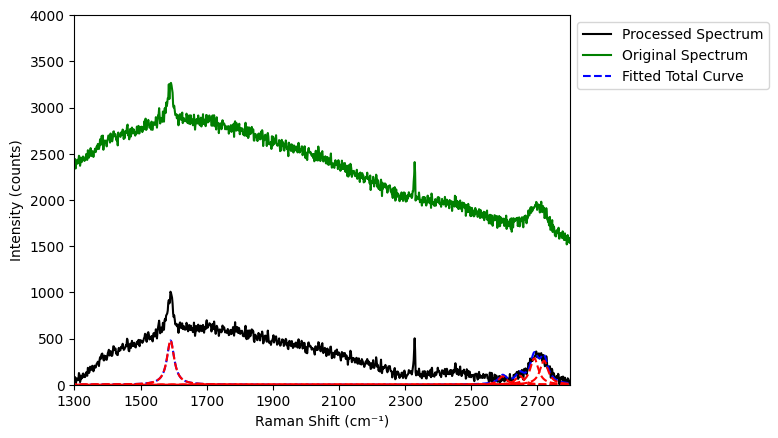

In [4]:
from ramanpl import RamanFit
import numpy as np

spectra, wavenumber = RamanFit.DataImporter.data_import(
    filename='Raman Sample 532nm 2L-Graphene.txt',
    x_range=(1300, 2900)    # Specify the x-axis range to read (in cm^-1)
)

# Exclude major Raman bands from baseline estimation
mask = np.ones_like(wavenumber, dtype=bool)
mask &= ~((wavenumber > 1500) & (wavenumber < 1700))   # G region
mask &= ~((wavenumber > 2320) & (wavenumber < 2380))   # spike region
mask &= ~((wavenumber > 2550) & (wavenumber < 2800))   # 2D region

baseline_setting={
    "method": "airpls",
    "lam": 3e7,
    "niter": 150,
    "tol": 1e-6,
    "mask": mask,
    "min_weight": 1e-3
}


raman_fit = RamanFit.RamanFit(
    spectra, wavenumber,
    materials=['2L-Gr'],
    substrate=None,
    normalize=False,
    background_remove=True,
    baseline_method=baseline_setting,
    smoothing=True,
    smooth_order=8
)


# Update the fitting bounds 
bounds_dict = {
    "G":     ([1570, 0, 0], [1610, 15, 20]),   # position, scale, amplitude

    "2D-1B": ([2595, 0, 0], [2625, 15, 20]),
    "2D-1A": ([2620, 0, 0], [2660, 15, 30]),
    "2D-2A": ([2660, 0, 0], [2705, 15, 30]),
    "2D-2B": ([2705, 0, 0], [2735, 15, 20]),
}


raman_fit.update_bounds(**bounds_dict)

# Remove Unecessary peaks
raman_fit.remove_peaks('D')             # 'D' peak around 1400 cm-1 is only needed if you think sample is doped, we remove it in this example

# Perform the fitting
params, params_cov = raman_fit.fit_spectrum()

# Plot the results with an offset and scale
xlim = [1300, 2800]
raman_fit.plot_fit(params,                          # The Lorentzian parameters fitted 
                   offset=0, scale=1,               # Plot offset or scale of fitted curve relative to raw data
                   x_lim=xlim, y_lim=[0,4000],      # set x-y axis limits
                
                   # set x-axis ticks
                   x_ticks=range(xlim[0],xlim[1],200)
                   )